# 정상-only GNSS 스푸핑 탐지 학습 Notebook

이 Notebook의 목적은 **개념 설명만 하는 것이 아니라**, 이미 만들어 둔 정상 GNSS-SDR tracking feature dataset으로 실제 모델을 학습하고 산출물을 저장하는 것입니다.

## 한 줄 목표

```text
정상 데이터만 학습한다.
새 데이터가 들어오면 정상 예측과 실제 관측이 얼마나 다른지 본다.
그 차이를 3가지 관점으로 나눈다.
```

3가지 관점은 다음입니다.

```text
1. Morphology surprise
   PRN별 E/P/L peak 모양이 정상 예측에서 벗어났는가?

2. Doppler/loop dynamics surprise
   PRN별 Doppler, code error, loop dynamics가 정상 예측에서 벗어났는가?

3. Multi-PRN coordinated distortion score
   여러 PRN에서 동시에 비슷한 이상이 생겼는가?
```

여기서는 `v1`, `v2` 같은 표현을 쓰지 않습니다. 이 Notebook은 그냥 **최종 실험 방향에 맞춘 실제 학습 절차**입니다.


## 0. 가장 중요한 질문: 학습 데이터가 3개 필요한가?

아닙니다. **원천 데이터는 하나입니다.**

원천 데이터는 정상 GNSS-SDR tracking dump에서 만든 다음 dataset입니다.

```text
normal_prn_node_windows.csv
normal_receiver_graph_windows.csv
```

다만 같은 정상 데이터를 3가지 관점으로 나누어 학습합니다.

```text
정상 tracking feature dataset
├── Morphology feature만 골라서 학습
│   └── E/P/L 비대칭, sharpness, prompt dominance 등
│
├── Doppler/loop feature만 골라서 학습
│   └── Doppler slope, code error, loop variance 등
│
└── Receiver-level relation feature를 학습
    └── 여러 PRN의 동시 변화, top-k, 공통모드 제거 관계 등
```

즉 필요한 것은 **3개의 별도 수집 데이터**가 아니라:

```text
하나의 정상 데이터셋
+ 그 안에서 분리한 3개의 feature group
+ 각각의 normal-only 모델/score
```

입니다.

## 각 학습이 배우는 것

### 1) Morphology 학습

```text
입력: 특정 PRN의 최근 K개 window morphology feature
출력: 같은 PRN의 다음 window morphology feature 예측
score: 실제 morphology - 예측 morphology
```

이것이 잡는 것:

```text
E/P/L 비대칭
peak sharpness 변화
Prompt dominance 변화
```

### 2) Doppler/loop dynamics 학습

```text
입력: 특정 PRN의 최근 K개 window Doppler/code/loop feature
출력: 같은 PRN의 다음 window Doppler/code/loop feature 예측
score: 실제 dynamics - 예측 dynamics
```

이것이 잡는 것:

```text
Doppler slope 이상
code error drift
carrier/code loop variance 변화
```

### 3) Multi-PRN relation 학습

```text
입력: receiver의 최근 K개 window relation feature
출력: 다음 receiver-level relation feature 예측
score: 실제 relation - 예측 relation
```

이것이 잡는 것:

```text
G05만 튐 → receiver-level score 낮음 또는 제한적
G05, G12, G21, G24가 동시에 흔들림 → receiver-level score 높음
```


## 1. 환경 설정과 데이터 경로

이 Notebook은 아래 dataset을 바로 읽습니다.

```text
artifacts/model_datasets/normal_multi_prn_morphology_dynamics_v2/
├── normal_prn_node_windows.csv
├── normal_receiver_graph_windows.csv
└── manifest.json
```

학습 결과는 아래에 저장합니다.

```text
artifacts/normal_only_prn_graph_training/
├── morphology_gru_predictor.pt
├── doppler_loop_gru_predictor.pt
├── relation_gru_predictor.pt
├── normal_only_training_summary.json
├── morphology_validation_prn_scores.csv
├── doppler_loop_validation_prn_scores.csv
└── relation_validation_receiver_scores.csv
```


In [2]:
from __future__ import annotations

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EmpiricalCovariance

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "artifacts" / "model_datasets" / "normal_multi_prn_morphology_dynamics_v2"
NODE_CSV = DATASET_DIR / "normal_prn_node_windows.csv"
GRAPH_CSV = DATASET_DIR / "normal_receiver_graph_windows.csv"
MANIFEST_JSON = DATASET_DIR / "manifest.json"

OUT_DIR = PROJECT_ROOT / "artifacts" / "normal_only_prn_graph_training"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
HISTORY_LEN = 10
EPOCHS = 20
BATCH_SIZE = 256
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATASET_DIR  =", DATASET_DIR)
print("OUT_DIR      =", OUT_DIR)
print("DEVICE       =", DEVICE)


PROJECT_ROOT = /home/ubuntu/projects/gnss-doppler-lab
DATASET_DIR  = /home/ubuntu/projects/gnss-doppler-lab/artifacts/model_datasets/normal_multi_prn_morphology_dynamics_v2
OUT_DIR      = /home/ubuntu/projects/gnss-doppler-lab/artifacts/normal_only_prn_graph_training
DEVICE       = cpu


## 2. Dataset 로드와 확인

여기서는 실제 학습할 row 수와 split을 확인합니다.

중요: split은 random window split이 아니라 **run 단위 split**입니다.  
인접 window가 train과 validation에 섞이면 성능이 과대평가될 수 있기 때문입니다.


In [3]:
assert NODE_CSV.exists(), NODE_CSV
assert GRAPH_CSV.exists(), GRAPH_CSV
assert MANIFEST_JSON.exists(), MANIFEST_JSON

node = pd.read_csv(NODE_CSV)
graph = pd.read_csv(GRAPH_CSV)
manifest = json.loads(MANIFEST_JSON.read_text())

print("node shape :", node.shape)
print("graph shape:", graph.shape)
print("node NaN   :", int(node.isna().sum().sum()))
print("graph NaN  :", int(graph.isna().sum().sum()))
print("runs       :", node["run_id"].nunique())
print("PRNs       :", node["prn"].nunique())
print("\nnode rows by split")
print(node.groupby("split").size())
print("\ngraph rows by split")
print(graph.groupby("split").size())

print("\ntracked PRN count summary")
print(graph["tracked_prn_count"].describe())


node shape : (15356, 64)
graph shape: (1302, 23)
node NaN   : 0
graph NaN  : 0
runs       : 10
PRNs       : 32

node rows by split
split
test_normal    2831
train          9811
val            2714
dtype: int64

graph rows by split
split
test_normal    236
train          830
val            236
dtype: int64

tracked PRN count summary
count    1302.000000
mean       11.794163
std         0.939702
min         1.000000
25%        11.000000
50%        12.000000
75%        13.000000
max        13.000000
Name: tracked_prn_count, dtype: float64


## 2.1 생성된 데이터 직접 보기

아래 셀은 모델 학습 전에 **생성된 데이터 자체**를 확인하는 구간입니다.

- `normal_prn_node_windows.csv`: 한 행이 `run/time window/PRN`입니다. E/P/L morphology와 Doppler/code loop feature가 들어갑니다.
- `normal_receiver_graph_windows.csv`: 한 행이 `run/time window`입니다. 같은 시간창에서 여러 PRN 사이의 관계 요약이 들어갑니다.

즉 이 두 표가 이후 통합 AI 모델의 입력이 됩니다.

In [4]:
from IPython.display import display

print("=== dataset files ===")
print("NODE_CSV    :", NODE_CSV)
print("GRAPH_CSV   :", GRAPH_CSV)
print("MANIFEST    :", MANIFEST_JSON)
print()

print("=== manifest 핵심 ===")
print("node rows :", manifest.get("node_rows", manifest.get("node_table", {}).get("row_count")))
print("graph rows:", manifest.get("graph_rows", manifest.get("graph_table", {}).get("row_count")))
print("splits    :", sorted(node["split"].unique()) if "split" in node.columns else "no split column")
print()

print("=== PRN node table sample: E/P/L morphology + Doppler/code dynamics ===")
node_preview_cols = [
    "run_id", "split", "label", "prn", "window_bin_s", "epoch_count",
    "near_sym_mean", "sharp_narrow_mean", "prompt_dominance_mean",
    "carrier_doppler_hz_mean", "carrier_doppler_hz_slope",
    "cn0_db_hz_mean", "code_error_chips_mean", "prompt_mag_cv",
]
node_preview_cols = [c for c in node_preview_cols if c in node.columns]
display(node[node_preview_cols].head(12))

print("=== Receiver graph table sample: multi-PRN relation summary ===")
graph_preview_cols = [
    "run_id", "split", "label", "window_bin_s", "tracked_prn_count", "prns",
    "morph_l2_median", "morph_l2_top3_mean", "morph_l2_std_across_prn",
    "near_sym_std_across_prn", "sharp_narrow_std_across_prn",
    "doppler_slope_common_removed_std", "code_error_slope_common_removed_std",
]
graph_preview_cols = [c for c in graph_preview_cols if c in graph.columns]
display(graph[graph_preview_cols].head(12))

print("=== run/split 요약 ===")
display(node.groupby(["split", "run_id"]).agg(
    node_rows=("prn", "size"),
    prn_count=("prn", "nunique"),
    first_window=("window_bin_s", "min"),
    last_window=("window_bin_s", "max"),
).reset_index())

print("=== tracked PRN count 분포 ===")
display(graph["tracked_prn_count"].describe().to_frame().T)


=== dataset files ===
NODE_CSV    : /home/ubuntu/projects/gnss-doppler-lab/artifacts/model_datasets/normal_multi_prn_morphology_dynamics_v2/normal_prn_node_windows.csv
GRAPH_CSV   : /home/ubuntu/projects/gnss-doppler-lab/artifacts/model_datasets/normal_multi_prn_morphology_dynamics_v2/normal_receiver_graph_windows.csv
MANIFEST    : /home/ubuntu/projects/gnss-doppler-lab/artifacts/model_datasets/normal_multi_prn_morphology_dynamics_v2/manifest.json

=== manifest 핵심 ===
node rows : 15356
graph rows: 1302
splits    : ['test_normal', 'train', 'val']

=== PRN node table sample: E/P/L morphology + Doppler/code dynamics ===


,run_id,split,label,prn,window_bin_s,epoch_count,near_sym_mean,sharp_narrow_mean,prompt_dominance_mean,carrier_doppler_hz_mean,carrier_doppler_hz_slope,cn0_db_hz_mean,code_error_chips_mean,prompt_mag_cv
0,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G08,0.5,1001,-0.024995,0.334128,0.607608,-508.142513,-21.468787,41.428855,-0.018747,0.201281
1,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G06,0.5,1001,-0.027967,0.360840,0.615034,2920.976439,60.219204,44.216578,-0.020975,0.151301
2,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G03,0.5,1001,-0.029738,0.339498,0.606458,1287.134417,0.273466,51.858059,-0.022304,0.101690
3,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G09,0.5,1001,-0.028613,0.350018,0.610630,719.000778,6.901273,48.014097,-0.021460,0.112638
4,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G04,0.5,1001,-0.051870,0.271938,0.583815,-387.144420,-0.188565,52.363754,-0.038902,0.170949
5,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G16,0.5,1001,-0.018877,0.392748,0.624972,776.444567,-27.603010,48.883460,-0.014157,0.089399
6,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G07,0.5,1001,-0.034089,0.303025,0.593465,3215.695495,3.324743,50.054816,-0.025567,0.110449
7,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G01,0.5,1000,-0.024226,0.378996,0.619828,-2173.419628,68.703790,51.699573,-0.018169,0.078882
8,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G17,0.5,1000,-0.028998,0.344990,0.608119,-1281.986742,52.924405,43.610875,-0.021748,0.142493
9,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,G22,0.5,1001,-0.026898,0.372010,0.618919,-375.415214,26.470071,52.589517,-0.020174,0.098050


=== Receiver graph table sample: multi-PRN relation summary ===


,run_id,split,label,window_bin_s,tracked_prn_count,prns,morph_l2_median,morph_l2_top3_mean,morph_l2_std_across_prn,near_sym_std_across_prn,sharp_narrow_std_across_prn,doppler_slope_common_removed_std,code_error_slope_common_removed_std
0,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,0.5,12,G01 G03 G04 G06 G07 G08 G09 G16 G17 G21 G22 G26,0.702370,0.734140,0.029045,0.008272,0.037766,30.363159,0.084540
1,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,1.0,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.765273,0.784346,0.064438,0.019972,0.146832,24.515916,0.039527
2,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,1.5,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.797871,0.823572,0.059201,0.017727,0.202283,24.126279,0.031938
3,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,2.0,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.824164,0.847283,0.064924,0.028022,0.209795,23.850282,0.011283
4,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,2.5,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.828245,0.847014,0.079956,0.017237,0.157950,2.135013,0.020131
5,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,3.0,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.828484,0.848340,0.075578,0.001738,0.121527,6.895605,0.020308
6,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,3.5,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.829811,0.850082,0.079232,0.013821,0.152393,0.386105,0.024471
7,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,4.0,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.829666,0.848953,0.078548,0.011541,0.154476,0.197432,0.014672
8,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,4.5,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.828535,0.848330,0.073120,0.002660,0.121347,0.266948,0.006126
9,global-brasilia-static-60s-2022_20220101T000000Z,train,normal,5.0,13,G01 G03 G04 G06 G07 G08 G09 G14 G16 G17 G21 G2...,0.829820,0.850080,0.039226,0.001820,0.240084,0.242672,0.006498


=== run/split 요약 ===


,split,run_id,node_rows,prn_count,first_window,last_window
0,test_normal,global-nairobi-static-60s-2022_20220101T000000Z,1298,11,0.5,59.0
1,test_normal,global-washington-dc-static-60s-2022_20220101T...,1533,13,0.5,59.0
2,train,global-brasilia-static-60s-2022_20220101T000000Z,1530,14,0.5,59.0
3,train,global-canberra-static-60s-2022_20220101T000000Z,1408,13,0.5,59.0
4,train,global-london-static-60s-2022_20220101T000000Z,1533,13,0.5,59.0
5,train,seoul-normal-s1-straight-90s-2022_20220101T000...,1988,12,0.5,89.0
6,train,seoul-normal-s2-circle-90s-2022_20220101T000000Z,2055,15,0.5,89.5
7,train,seoul-normal-static-60s-2022_20220101T000000Z,1297,11,0.5,59.5
8,val,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,2078,15,0.5,89.0
9,val,seoul-normal-static-30s-2022_20220101T000000Z,636,11,0.5,29.0


=== tracked PRN count 분포 ===


,count,mean,std,min,25%,50%,75%,max
tracked_prn_count,1302.0,11.794163,0.939702,1.0,11.0,12.0,13.0,13.0


## 3. Feature group 정의

여기서 세 학습을 명확히 분리합니다.

## 3.1 Morphology feature

PRN별 correlation peak 모양을 나타냅니다.

```text
near_sym
sharp_narrow
prompt_dominance
peak_center_3tap
shape_entropy_3tap
norm_prompt_share
```

각 feature의 `mean/std/slope/delta`를 사용합니다.

## 3.2 Doppler/loop dynamics feature

PRN별 tracking loop의 시간 변화를 나타냅니다.

```text
carrier_doppler_hz
doppler_abs
code_error_chips
code_freq_chips
cn0_db_hz
prompt_mag_cv
```

단, power shortcut을 피하기 위해 main feature에서는 다음을 제외합니다.

```text
prompt_mag_mean
cn0_db_hz_mean
```

## 3.3 Relation feature

같은 시간대 여러 PRN이 동시에 어떻게 움직이는지 나타냅니다.

```text
morph_l2_top3_mean
morph_l2_std_across_prn
doppler_slope_common_removed_std
code_error_slope_common_removed_std
```


In [3]:
MORPH_BASES = [
    "near_sym",
    "sharp_narrow",
    "prompt_dominance",
    "peak_center_3tap",
    "shape_entropy_3tap",
    "norm_prompt_share",
]
DYNAMICS_BASES = [
    "carrier_doppler_hz",
    "doppler_abs",
    "code_error_chips",
    "code_freq_chips",
    "cn0_db_hz",
    "prompt_mag",
]
SUMMARY_SUFFIXES = ["mean", "std", "slope", "delta"]

morph_cols = [f"{b}_{s}" for b in MORPH_BASES for s in SUMMARY_SUFFIXES if f"{b}_{s}" in node.columns]
all_dopp_cols = [f"{b}_{s}" for b in DYNAMICS_BASES for s in SUMMARY_SUFFIXES if f"{b}_{s}" in node.columns]
power_shortcut_cols = {"prompt_mag_mean", "cn0_db_hz_mean"}
dopp_cols = [c for c in all_dopp_cols if c not in power_shortcut_cols]
if "prompt_mag_cv" in node.columns:
    dopp_cols.append("prompt_mag_cv")
dopp_cols = list(dict.fromkeys(dopp_cols))

relation_cols = [
    "morph_l2_median",
    "morph_l2_top3_mean",
    "morph_l2_std_across_prn",
    "near_sym_std_across_prn",
    "sharp_narrow_std_across_prn",
    "prompt_dominance_std_across_prn",
    "peak_center_std_across_prn",
    "shape_entropy_std_across_prn",
    "doppler_slope_common_removed_std",
    "code_error_slope_common_removed_std",
    "cn0_std_median",
    "prompt_mag_cv_median",
]
relation_cols = [c for c in relation_cols if c in graph.columns]

print("Morphology feature count:", len(morph_cols))
print(morph_cols)
print("\nDoppler/loop feature count:", len(dopp_cols))
print(dopp_cols)
print("\nRelation feature count:", len(relation_cols))
print(relation_cols)


Morphology feature count: 24
['near_sym_mean', 'near_sym_std', 'near_sym_slope', 'near_sym_delta', 'sharp_narrow_mean', 'sharp_narrow_std', 'sharp_narrow_slope', 'sharp_narrow_delta', 'prompt_dominance_mean', 'prompt_dominance_std', 'prompt_dominance_slope', 'prompt_dominance_delta', 'peak_center_3tap_mean', 'peak_center_3tap_std', 'peak_center_3tap_slope', 'peak_center_3tap_delta', 'shape_entropy_3tap_mean', 'shape_entropy_3tap_std', 'shape_entropy_3tap_slope', 'shape_entropy_3tap_delta', 'norm_prompt_share_mean', 'norm_prompt_share_std', 'norm_prompt_share_slope', 'norm_prompt_share_delta']

Doppler/loop feature count: 23
['carrier_doppler_hz_mean', 'carrier_doppler_hz_std', 'carrier_doppler_hz_slope', 'carrier_doppler_hz_delta', 'doppler_abs_mean', 'doppler_abs_std', 'doppler_abs_slope', 'doppler_abs_delta', 'code_error_chips_mean', 'code_error_chips_std', 'code_error_chips_slope', 'code_error_chips_delta', 'code_freq_chips_mean', 'code_freq_chips_std', 'code_freq_chips_slope', 'cod

## 4. 학습/검증 데이터 만들기

각 feature group은 train normal 통계로만 scaling합니다.

```text
train normal → scaler fit
val/test/external → scaler transform only
```

이 원칙을 지켜야 external spoofing data 평가에서 leakage가 없습니다.


In [4]:
train_node_raw = node[node["split"] == "train"].copy()
val_node_raw = node[node["split"] == "val"].copy()
test_node_raw = node[node["split"] == "test_normal"].copy()

train_graph_raw = graph[graph["split"] == "train"].copy()
val_graph_raw = graph[graph["split"] == "val"].copy()
test_graph_raw = graph[graph["split"] == "test_normal"].copy()

assert len(train_node_raw) and len(val_node_raw)
assert len(train_graph_raw) and len(val_graph_raw)

def scale_group(train_df, val_df, test_df, cols):
    scaler = RobustScaler().fit(train_df[cols].to_numpy(dtype=float))
    out = []
    for df in [train_df.copy(), val_df.copy(), test_df.copy()]:
        df.loc[:, cols] = scaler.transform(df[cols].to_numpy(dtype=float))
        out.append(df)
    return scaler, out[0], out[1], out[2]

morph_scaler, train_morph, val_morph, test_morph = scale_group(train_node_raw, val_node_raw, test_node_raw, morph_cols)
dopp_scaler, train_dopp, val_dopp, test_dopp = scale_group(train_node_raw, val_node_raw, test_node_raw, dopp_cols)
rel_scaler, train_rel, val_rel, test_rel = scale_group(train_graph_raw, val_graph_raw, test_graph_raw, relation_cols)

print("train_morph", train_morph.shape, "val_morph", val_morph.shape)
print("train_dopp ", train_dopp.shape, "val_dopp ", val_dopp.shape)
print("train_rel  ", train_rel.shape, "val_rel  ", val_rel.shape)


train_morph (9811, 64) val_morph (2714, 64)
train_dopp  (9811, 64) val_dopp  (2714, 64)
train_rel   (830, 23) val_rel   (236, 23)


## 5. 정상 데이터 모습 보기

아래 heatmap은 정상 run 하나에서 PRN별 raw morphology indicator를 보여줍니다.

외부 spoofing data를 처리하면 같은 그림에서 여러 PRN이 동시에 밝아지는지 확인합니다.


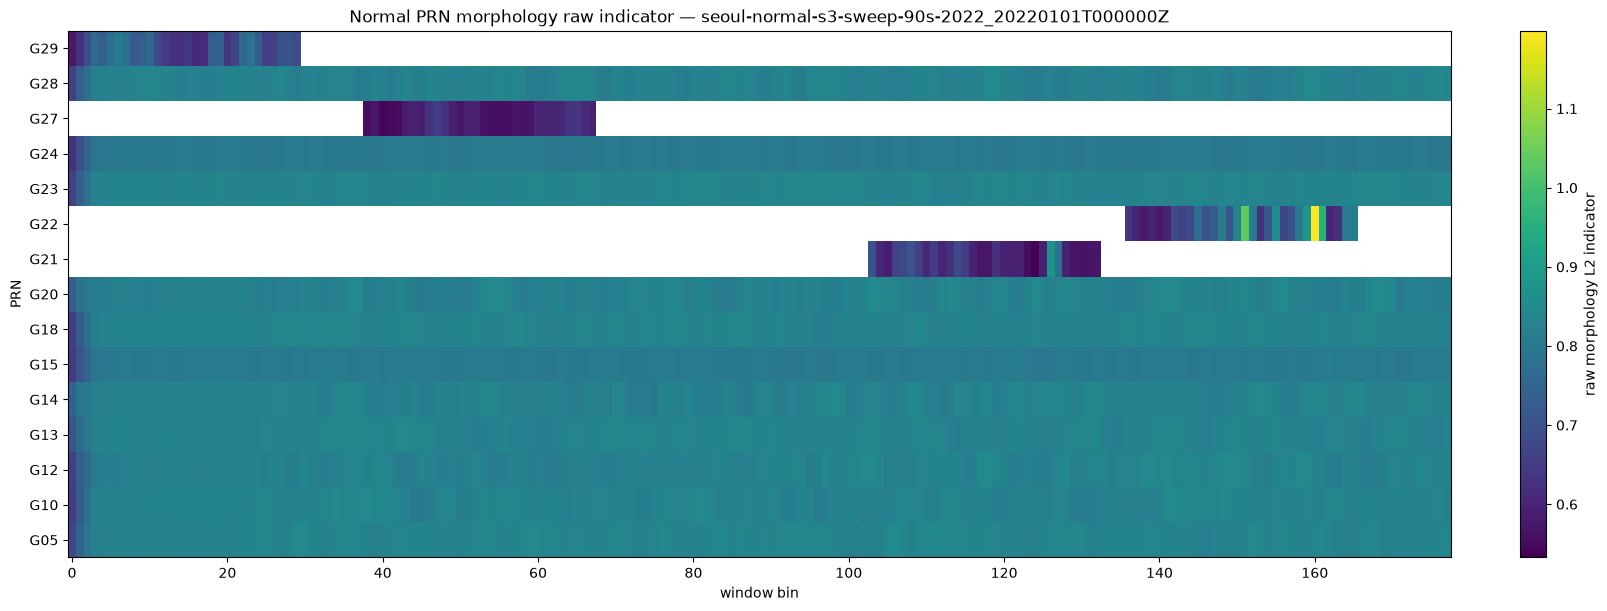

window_bin_s,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0
prn,,,,,,,,
G05,0.675293,0.746069,0.794291,0.823038,0.827244,0.828663,0.827681,0.828701
G10,0.652338,0.726278,0.777775,0.823311,0.829002,0.829784,0.830145,0.829475
G12,0.659020,0.735444,0.768049,0.807709,0.820087,0.820379,0.815061,0.821420
G13,0.709095,0.768116,0.797590,0.825909,0.829383,0.831341,0.832351,0.832375
G14,0.746668,0.787710,0.802635,0.820623,0.824183,0.824380,0.829131,0.829772


In [5]:
selected_run = "seoul-normal-s3-sweep-90s-2022_20220101T000000Z"
if selected_run not in set(node["run_id"]):
    selected_run = sorted(node["run_id"].unique())[0]

run_node = node[node["run_id"] == selected_run].copy()
run_node["morph_l2_raw"] = np.sqrt(
    run_node["near_sym_mean"]**2
    + run_node["sharp_narrow_mean"]**2
    + run_node["prompt_dominance_mean"]**2
    + run_node["peak_center_3tap_mean"]**2
)
heat = run_node.pivot_table(index="prn", columns="window_bin_s", values="morph_l2_raw", aggfunc="mean")

fig, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
im = ax.imshow(heat.to_numpy(), aspect="auto", interpolation="nearest", origin="lower")
ax.set_title(f"Normal PRN morphology raw indicator — {selected_run}")
ax.set_xlabel("window bin")
ax.set_ylabel("PRN")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
fig.colorbar(im, ax=ax, label="raw morphology L2 indicator")
plt.show()

heat.iloc[:5, :8]


## 6. 공통 학습 함수

세 학습은 모두 같은 원리입니다.

```text
최근 K개 window → 다음 window 예측
prediction error = anomaly score
```

차이는 입력 feature group입니다.

```text
Morphology 학습: morph_cols 사용
Doppler/loop 학습: dopp_cols 사용
Relation 학습: relation_cols 사용
```


In [6]:
class SequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, feature_cols: list[str], history_len: int, group_cols: list[str], time_col: str):
        self.X, self.y, self.meta = [], [], []
        sort_cols = group_cols + [time_col]
        for key, g in df.sort_values(sort_cols).groupby(group_cols):
            vals = g[feature_cols].to_numpy(dtype=np.float32)
            times = g[time_col].to_numpy(dtype=float)
            run_ids = g["run_id"].to_numpy() if "run_id" in g.columns else np.array([None] * len(g))
            for i in range(history_len, len(g)):
                self.X.append(vals[i-history_len:i])
                self.y.append(vals[i])
                meta = {"window_bin_s": float(times[i])}
                if isinstance(key, tuple):
                    for name, value in zip(group_cols, key):
                        meta[name] = value
                else:
                    meta[group_cols[0]] = key
                if "run_id" not in meta and run_ids[i] is not None:
                    meta["run_id"] = run_ids[i]
                self.meta.append(meta)
        self.X = torch.tensor(np.stack(self.X), dtype=torch.float32) if self.X else torch.empty(0, history_len, len(feature_cols))
        self.y = torch.tensor(np.stack(self.y), dtype=torch.float32) if self.y else torch.empty(0, len(feature_cols))
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class GRUPredictor(nn.Module):
    def __init__(self, n_features: int, hidden: int = 96):
        super().__init__()
        self.gru = nn.GRU(input_size=n_features, hidden_size=hidden, batch_first=True)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_features),
        )
    def forward(self, x):
        h, _ = self.gru(x)
        return self.head(h[:, -1, :])

def train_predictor(name: str, train_df: pd.DataFrame, val_df: pd.DataFrame, feature_cols: list[str], group_cols: list[str], time_col: str):
    train_ds = SequenceDataset(train_df, feature_cols, HISTORY_LEN, group_cols, time_col)
    val_ds = SequenceDataset(val_df, feature_cols, HISTORY_LEN, group_cols, time_col)
    print(f"[{name}] train sequences={len(train_ds)} val sequences={len(val_ds)} features={len(feature_cols)}")
    assert len(train_ds) > 10, f"not enough train sequences for {name}"
    assert len(val_ds) > 0, f"not enough val sequences for {name}"

    model = GRUPredictor(n_features=len(feature_cols), hidden=96).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    history = []
    for ep in range(1, EPOCHS + 1):
        model.train()
        losses = []
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(float(loss.detach().cpu()))
        model.eval()
        with torch.no_grad():
            val_losses = []
            for i in range(0, len(val_ds), BATCH_SIZE):
                xb = val_ds.X[i:i+BATCH_SIZE].to(DEVICE)
                yb = val_ds.y[i:i+BATCH_SIZE].to(DEVICE)
                val_losses.append(float(loss_fn(model(xb), yb).detach().cpu()))
        rec = {"epoch": ep, "train_loss": float(np.mean(losses)), "val_loss": float(np.mean(val_losses))}
        history.append(rec)
        if ep in [1, 2, 5, 10, 15, 20] or ep == EPOCHS:
            print(f"[{name}]", rec)
    return model, train_ds, val_ds, pd.DataFrame(history)

def score_dataset(model, ds: SequenceDataset, score_prefix: str):
    model.eval()
    rows = []
    with torch.no_grad():
        for i in range(0, len(ds), BATCH_SIZE):
            xb = ds.X[i:i+BATCH_SIZE].to(DEVICE)
            yb = ds.y[i:i+BATCH_SIZE].cpu().numpy()
            pred = model(xb).cpu().numpy()
            err = np.abs(pred - yb)
            for j in range(len(err)):
                meta = dict(ds.meta[i+j])
                meta[f"{score_prefix}_l1_mean"] = float(err[j].mean())
                meta[f"{score_prefix}_l2"] = float(np.sqrt((err[j] ** 2).mean()))
                rows.append(meta)
    return pd.DataFrame(rows)


## 7. 실제 학습 1 — Morphology predictor

이 모델은 PRN별 E/P/L peak morphology의 정상 시간 변화를 학습합니다.

수식으로는 다음입니다.

```text
입력:  φ_i(t-K+1), ..., φ_i(t)
출력:  φ_hat_i(t+1)
score: S_morph_i(t+1) = ||φ_i(t+1) - φ_hat_i(t+1)||
```

receiver-level에서는 여러 PRN의 morphology error를 모아 `median`, `top3 mean`, `threshold 초과 비율`을 봅니다.


In [7]:
morph_model, morph_train_ds, morph_val_ds, morph_history = train_predictor(
    name="morphology",
    train_df=train_morph,
    val_df=val_morph,
    feature_cols=morph_cols,
    group_cols=["run_id", "prn"],
    time_col="window_bin_s",
)

morph_val_scores = score_dataset(morph_model, morph_val_ds, "S_morph")
morph_thr = float(np.quantile(morph_val_scores["S_morph_l1_mean"], 0.995))
print("S_morph validation q99.5 threshold:", morph_thr)

morph_history.to_csv(OUT_DIR / "morphology_training_history.csv", index=False)
morph_val_scores.to_csv(OUT_DIR / "morphology_validation_prn_scores.csv", index=False)
torch.save({
    "model_state_dict": morph_model.state_dict(),
    "feature_cols": morph_cols,
    "history_len": HISTORY_LEN,
    "score_threshold_q995_val": morph_thr,
    "dataset": str(NODE_CSV),
}, OUT_DIR / "morphology_gru_predictor.pt")

morph_val_scores.head()


[morphology] train sequences=9032 val sequences=2454 features=24


[morphology] {'epoch': 1, 'train_loss': 0.3980531357228756, 'val_loss': 0.5633600562810898}


[morphology] {'epoch': 2, 'train_loss': 0.3478280690809091, 'val_loss': 0.5067198514938355}


[morphology] {'epoch': 5, 'train_loss': 0.2607642917169465, 'val_loss': 0.36149153038859366}


[morphology] {'epoch': 10, 'train_loss': 0.23839587966601053, 'val_loss': 0.344933008402586}


[morphology] {'epoch': 15, 'train_loss': 0.2324406032760938, 'val_loss': 0.3438864327967167}


[morphology] {'epoch': 20, 'train_loss': 0.227684632771545, 'val_loss': 0.3442894332110882}
S_morph validation q99.5 threshold: 9.483812427520759


,window_bin_s,run_id,prn,S_morph_l1_mean,S_morph_l2
0,5.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.204067,0.330876
1,6.0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.200726,0.268271
2,6.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.126380,0.162457
3,7.0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.190432,0.263217
4,7.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.074676,0.099205


## 8. 실제 학습 2 — Doppler/loop dynamics predictor

이 모델은 PRN별 Doppler/code/loop feature의 정상 시간 변화를 학습합니다.

수식으로는 다음입니다.

```text
입력:  r_i(t-K+1), ..., r_i(t)
출력:  r_hat_i(t+1)
score: S_dopp_i(t+1) = ||r_i(t+1) - r_hat_i(t+1)||
```

여기서 `r_i`는 아직 완전한 ephemeris 기반 Doppler residual이 아니라, 현재 tracking dump에서 얻은 Doppler/code/loop dynamics feature입니다.  
다음 단계에서 predicted Doppler가 들어오면 다음 형태로 바꿉니다.

```text
r_i(t) = observed_doppler_i(t) - predicted_doppler_i(t)
r_i_prime(t) = r_i(t) - common_mode(t)
```


In [8]:
dopp_model, dopp_train_ds, dopp_val_ds, dopp_history = train_predictor(
    name="doppler_loop",
    train_df=train_dopp,
    val_df=val_dopp,
    feature_cols=dopp_cols,
    group_cols=["run_id", "prn"],
    time_col="window_bin_s",
)

dopp_val_scores = score_dataset(dopp_model, dopp_val_ds, "S_dopp")
dopp_thr = float(np.quantile(dopp_val_scores["S_dopp_l1_mean"], 0.995))
print("S_dopp validation q99.5 threshold:", dopp_thr)

dopp_history.to_csv(OUT_DIR / "doppler_loop_training_history.csv", index=False)
dopp_val_scores.to_csv(OUT_DIR / "doppler_loop_validation_prn_scores.csv", index=False)
torch.save({
    "model_state_dict": dopp_model.state_dict(),
    "feature_cols": dopp_cols,
    "history_len": HISTORY_LEN,
    "score_threshold_q995_val": dopp_thr,
    "dataset": str(NODE_CSV),
}, OUT_DIR / "doppler_loop_gru_predictor.pt")

dopp_val_scores.head()


[doppler_loop] train sequences=9032 val sequences=2454 features=23


[doppler_loop] {'epoch': 1, 'train_loss': 0.39380504770411384, 'val_loss': 0.48744447231292726}


[doppler_loop] {'epoch': 2, 'train_loss': 0.3524538576602936, 'val_loss': 0.4607751876115799}


[doppler_loop] {'epoch': 5, 'train_loss': 0.29709582320517963, 'val_loss': 0.3956293135881424}


[doppler_loop] {'epoch': 10, 'train_loss': 0.26065514526433414, 'val_loss': 0.3931308686733246}


[doppler_loop] {'epoch': 15, 'train_loss': 0.23768352799945408, 'val_loss': 0.3966454789042473}


[doppler_loop] {'epoch': 20, 'train_loss': 0.22215351545148426, 'val_loss': 0.3831279776990414}
S_dopp validation q99.5 threshold: 7.301503698825851


,window_bin_s,run_id,prn,S_dopp_l1_mean,S_dopp_l2
0,5.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.217997,0.324908
1,6.0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.208294,0.279420
2,6.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.180332,0.264320
3,7.0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.295180,0.492924
4,7.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,G05,0.134092,0.243058


## 9. 실제 학습 3 — Multi-PRN relation predictor

이 모델은 receiver-level relation feature의 정상 시간 변화를 학습합니다.

PRN 하나가 아니라 같은 시간대 여러 PRN을 묶은 receiver window를 봅니다.

```text
입력:  R(t-K+1), ..., R(t)
출력:  R_hat(t+1)
score: S_rel(t+1) = ||R(t+1) - R_hat(t+1)||
```

여기서 `R(t)`는 다음 같은 relation feature입니다.

```text
morph_l2_top3_mean
morph_l2_std_across_prn
doppler_slope_common_removed_std
code_error_slope_common_removed_std
```

즉 여러 PRN이 동시에 흔들리는지를 receiver-level로 학습합니다.


In [9]:
rel_model, rel_train_ds, rel_val_ds, rel_history = train_predictor(
    name="multi_prn_relation",
    train_df=train_rel,
    val_df=val_rel,
    feature_cols=relation_cols,
    group_cols=["run_id"],
    time_col="window_bin_s",
)

rel_val_scores = score_dataset(rel_model, rel_val_ds, "S_rel")
rel_thr = float(np.quantile(rel_val_scores["S_rel_l1_mean"], 0.995))
print("S_rel validation q99.5 threshold:", rel_thr)

rel_history.to_csv(OUT_DIR / "relation_training_history.csv", index=False)
rel_val_scores.to_csv(OUT_DIR / "relation_validation_receiver_scores.csv", index=False)
torch.save({
    "model_state_dict": rel_model.state_dict(),
    "feature_cols": relation_cols,
    "history_len": HISTORY_LEN,
    "score_threshold_q995_val": rel_thr,
    "dataset": str(GRAPH_CSV),
}, OUT_DIR / "relation_gru_predictor.pt")

rel_val_scores.head()


[multi_prn_relation] train sequences=770 val sequences=216 features=12
[multi_prn_relation] {'epoch': 1, 'train_loss': 0.9245588537305593, 'val_loss': 2.1599905490875244}


[multi_prn_relation] {'epoch': 2, 'train_loss': 1.597011923789978, 'val_loss': 2.096489906311035}


[multi_prn_relation] {'epoch': 5, 'train_loss': 1.4293383061885834, 'val_loss': 1.9106411933898926}


[multi_prn_relation] {'epoch': 10, 'train_loss': 0.7245068438351154, 'val_loss': 1.5711352825164795}


[multi_prn_relation] {'epoch': 15, 'train_loss': 1.3625334650278091, 'val_loss': 1.232300877571106}


[multi_prn_relation] {'epoch': 20, 'train_loss': 0.5034980028867722, 'val_loss': 0.9622495770454407}
S_rel validation q99.5 threshold: 5.629564726352703


,window_bin_s,run_id,S_rel_l1_mean,S_rel_l2
0,5.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,4.269249,9.185913
1,6.0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,2.288548,3.675512
2,6.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,1.792671,2.372645
3,7.0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,1.486689,2.046412
4,7.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,1.816928,2.554682


## 10. 세 score를 한 화면에서 확인

여기서는 validation 정상 데이터에서 세 score 분포를 봅니다.

정상 validation에서 q99.5 threshold를 잡아두면, 외부 spoofing data에서는 같은 모델과 같은 threshold로 비교합니다.


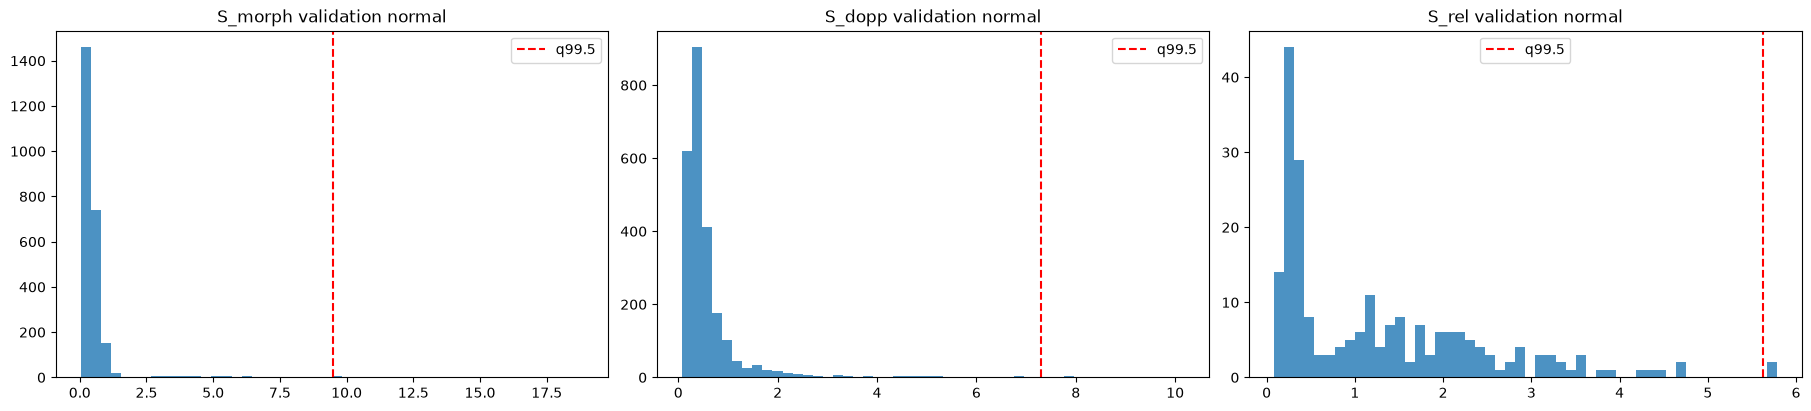

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

axes[0].hist(morph_val_scores["S_morph_l1_mean"], bins=50, alpha=0.8)
axes[0].axvline(morph_thr, color="red", linestyle="--", label="q99.5")
axes[0].set_title("S_morph validation normal")
axes[0].legend()

axes[1].hist(dopp_val_scores["S_dopp_l1_mean"], bins=50, alpha=0.8)
axes[1].axvline(dopp_thr, color="red", linestyle="--", label="q99.5")
axes[1].set_title("S_dopp validation normal")
axes[1].legend()

axes[2].hist(rel_val_scores["S_rel_l1_mean"], bins=50, alpha=0.8)
axes[2].axvline(rel_thr, color="red", linestyle="--", label="q99.5")
axes[2].set_title("S_rel validation normal")
axes[2].legend()

plt.show()


## 11. Receiver-level aggregation

PRN별 score인 `S_morph_i`, `S_dopp_i`는 receiver 시간창으로 모읍니다.

```text
receiver S_morph(t): PRN별 morphology error의 median/top3 mean/fraction above threshold
receiver S_dopp(t): PRN별 doppler-loop error의 median/top3 mean/fraction above threshold
receiver S_rel(t): receiver-level relation prediction error
```

최종 score는 이렇게 합칠 수 있습니다.

```text
S_total(t) = α S_morph_receiver(t) + β S_dopp_receiver(t) + γ S_rel(t)
```

현재 Notebook에서는 우선 각 score를 따로 저장합니다. 외부 ds4 feature가 생기면 같은 방식으로 timeline을 만듭니다.


In [11]:
def receiver_aggregate_prn_score(score_df: pd.DataFrame, score_col: str, threshold: float) -> pd.DataFrame:
    rows = []
    for (run_id, t), g in score_df.groupby(["run_id", "window_bin_s"], sort=True):
        s = g[score_col].to_numpy(dtype=float)
        rows.append({
            "run_id": run_id,
            "window_bin_s": float(t),
            "tracked_prn_count": int(g["prn"].nunique()),
            f"{score_col}_median": float(np.median(s)),
            f"{score_col}_top3_mean": float(np.sort(s)[-min(3, len(s)):].mean()),
            f"{score_col}_frac_above_thr": float(np.mean(s > threshold)),
        })
    return pd.DataFrame(rows)

morph_receiver = receiver_aggregate_prn_score(morph_val_scores, "S_morph_l1_mean", morph_thr)
dopp_receiver = receiver_aggregate_prn_score(dopp_val_scores, "S_dopp_l1_mean", dopp_thr)

morph_receiver.to_csv(OUT_DIR / "morphology_validation_receiver_scores.csv", index=False)
dopp_receiver.to_csv(OUT_DIR / "doppler_loop_validation_receiver_scores.csv", index=False)

print("morph_receiver", morph_receiver.shape)
print("dopp_receiver ", dopp_receiver.shape)
print("rel_val_scores", rel_val_scores.shape)
display(morph_receiver.head())
display(dopp_receiver.head())
display(rel_val_scores.head())


morph_receiver (216, 6)
dopp_receiver  (216, 6)
rel_val_scores (216, 4)


,run_id,window_bin_s,tracked_prn_count,S_morph_l1_mean_median,S_morph_l1_mean_top3_mean,S_morph_l1_mean_frac_above_thr
0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,5.5,12,0.240893,1.475781,0.0
1,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,6.0,12,0.181975,1.276364,0.0
2,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,6.5,12,0.193608,1.709849,0.0
3,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,7.0,12,0.228111,1.348138,0.0
4,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,7.5,12,0.188673,2.124880,0.0


,run_id,window_bin_s,tracked_prn_count,S_dopp_l1_mean_median,S_dopp_l1_mean_top3_mean,S_dopp_l1_mean_frac_above_thr
0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,5.5,12,0.297383,7.433788,0.166667
1,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,6.0,12,0.214298,5.433752,0.083333
2,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,6.5,12,0.205354,4.336526,0.083333
3,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,7.0,12,0.244277,4.173192,0.000000
4,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,7.5,12,0.190185,2.480935,0.000000


,window_bin_s,run_id,S_rel_l1_mean,S_rel_l2
0,5.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,4.269249,9.185913
1,6.0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,2.288548,3.675512
2,6.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,1.792671,2.372645
3,7.0,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,1.486689,2.046412
4,7.5,seoul-normal-s3-sweep-90s-2022_20220101T000000Z,1.816928,2.554682


## 12. 저장된 모델과 산출물 확인

여기까지 실행되면 실제 학습 결과가 파일로 저장됩니다.


In [12]:
summary = {
    "dataset_dir": str(DATASET_DIR),
    "node_csv": str(NODE_CSV),
    "graph_csv": str(GRAPH_CSV),
    "history_len": HISTORY_LEN,
    "epochs": EPOCHS,
    "device": DEVICE,
    "models": {
        "morphology": str(OUT_DIR / "morphology_gru_predictor.pt"),
        "doppler_loop": str(OUT_DIR / "doppler_loop_gru_predictor.pt"),
        "relation": str(OUT_DIR / "relation_gru_predictor.pt"),
    },
    "thresholds_validation_q995": {
        "S_morph_l1_mean": morph_thr,
        "S_dopp_l1_mean": dopp_thr,
        "S_rel_l1_mean": rel_thr,
    },
    "feature_counts": {
        "morphology": len(morph_cols),
        "doppler_loop": len(dopp_cols),
        "relation": len(relation_cols),
    },
    "sequence_counts": {
        "morphology_train": len(morph_train_ds),
        "morphology_val": len(morph_val_ds),
        "doppler_loop_train": len(dopp_train_ds),
        "doppler_loop_val": len(dopp_val_ds),
        "relation_train": len(rel_train_ds),
        "relation_val": len(rel_val_ds),
    },
}

(OUT_DIR / "normal_only_training_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False))
print(json.dumps(summary, indent=2, ensure_ascii=False))

print("\nFiles in OUT_DIR:")
for p in sorted(OUT_DIR.glob("*")):
    print(p.name, p.stat().st_size, "bytes")


{
  "dataset_dir": "/home/ubuntu/projects/gnss-doppler-lab/artifacts/model_datasets/normal_multi_prn_morphology_dynamics_v2",
  "node_csv": "/home/ubuntu/projects/gnss-doppler-lab/artifacts/model_datasets/normal_multi_prn_morphology_dynamics_v2/normal_prn_node_windows.csv",
  "graph_csv": "/home/ubuntu/projects/gnss-doppler-lab/artifacts/model_datasets/normal_multi_prn_morphology_dynamics_v2/normal_receiver_graph_windows.csv",
  "history_len": 10,
  "epochs": 20,
  "device": "cpu",
  "models": {
    "morphology": "/home/ubuntu/projects/gnss-doppler-lab/artifacts/normal_only_prn_graph_training/morphology_gru_predictor.pt",
    "doppler_loop": "/home/ubuntu/projects/gnss-doppler-lab/artifacts/normal_only_prn_graph_training/doppler_loop_gru_predictor.pt",
    "relation": "/home/ubuntu/projects/gnss-doppler-lab/artifacts/normal_only_prn_graph_training/relation_gru_predictor.pt"
  },
  "thresholds_validation_q995": {
    "S_morph_l1_mean": 9.483812427520759,
    "S_dopp_l1_mean": 7.30150369

## 13. TEXBAT ds4 external validation 연결

이제 정상 모델은 저장됐습니다. 다음은 ds4를 같은 feature schema로 처리해서 아래 절차를 반복하면 됩니다.

```text
TEXBAT ds4.bin
→ GNSS-SDR tracking dump
→ normal_prn_node_windows와 같은 node feature 생성
→ normal_receiver_graph_windows와 같은 relation feature 생성
→ 저장된 scaler/model/threshold 적용
→ S_morph, S_dopp, S_rel timeline 생성
```

중요:

```text
ds4는 학습에 사용하지 않는다.
ds4는 외부 검증에만 사용한다.
```


In [13]:
TEXBAT_RAW = PROJECT_ROOT / "data" / "external" / "texbat" / "raw" / "ds4.bin"
TEXBAT_STATUS = PROJECT_ROOT / "data" / "external" / "texbat" / "manifests" / "download_status.json"
print("ds4 raw exists:", TEXBAT_RAW.exists(), TEXBAT_RAW)
if TEXBAT_RAW.exists():
    print("ds4 size GB:", TEXBAT_RAW.stat().st_size / 1e9)
if TEXBAT_STATUS.exists():
    print(json.dumps(json.loads(TEXBAT_STATUS.read_text()), indent=2, ensure_ascii=False)[:2000])

expected_ds4_feature = PROJECT_ROOT / "artifacts" / "model_datasets" / "texbat_ds4_multi_prn_morphology_dynamics"
print("expected ds4 feature dir:", expected_ds4_feature)
print("feature dir exists:", expected_ds4_feature.exists())


ds4 raw exists: True /home/ubuntu/projects/gnss-doppler-lab/data/external/texbat/raw/ds4.bin
ds4 size GB: 12.821987328
{
  "retrieved_utc": "2026-07-17T10:16:32.584585+00:00",
  "root": "data/external/texbat",
  "source": "scidb",
  "results": [
    {
      "file": "ds4.bin",
      "status": "downloaded",
      "source_url": "https://china.scidb.cn/download?fileId=638f05ff8c39720bda8331bd",
      "bytes": 12821987328,
      "md5": "1beffc0dee6cd72972cec55ba10efe1d",
      "sha256": "1fff2b048a00732686bb1d77a13941da81c9fac648ca3695a9028f4ee3485285"
    }
  ]
}
expected ds4 feature dir: /home/ubuntu/projects/gnss-doppler-lab/artifacts/model_datasets/texbat_ds4_multi_prn_morphology_dynamics
feature dir exists: False
